# Wang Chong arXiv:2304.11864v2 #

## 计算单粒子能带H0 ##

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm
from quspin.basis import spinless_fermion_basis_1d
from quspin.operators import hamiltonian
from quspin.basis import spinless_fermion_basis_general
from quspin.tools.block_tools import block_diag_hamiltonian
import math as math
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
import time

In [153]:
# 转角 (unit in rad)
theta = np.radians(3.89)

# MoTe2晶格常数 (unit in Angstrom)
a0 = 3.52

# moire晶格常数 (unit in Angstrom)
aM = a0 / (2 * np.sin(theta / 2)) 

#原胞面积
A_cell= np.sqrt(3)/2 * aM**2 #unit in Angstrom^2

# 倒格矢量长度 (unit in Angstrom^-1)
bM = 4*np.pi/(np.sqrt(3)*aM) 

# 所有倒格矢量
angles = np.array([0, 1*np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3]) 
b = bM * np.stack([np.cos(angles), np.sin(angles)], axis=1) 

# moire周期势V和psi （V unit in eV, psi unit in rad）
V = 20.8e-3
psi = np.radians(107.7) 

#平面波截断阶数
Nbloch = 5

# hbar^2/2m* (unit in eV·Angstrom^+2) 
m_star = 0.6 #有效质量
h2m = 3.8099 / m_star 
#h2m = 0.495*a0**2 #(https://arxiv.org/pdf/2101.01258)

# 隧穿幅度 （unit in eV）
w = -23.8e-3 

#高对称点晶格动量 K_t 对应 K_+ ， K_b 对应 K_-
Kt = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), +np.sin(np.pi/6)], axis=0) 
Kb = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), -np.sin(np.pi/6)], axis=0) 

100%|██████████| 50/50 [00:06<00:00,  7.96it/s]


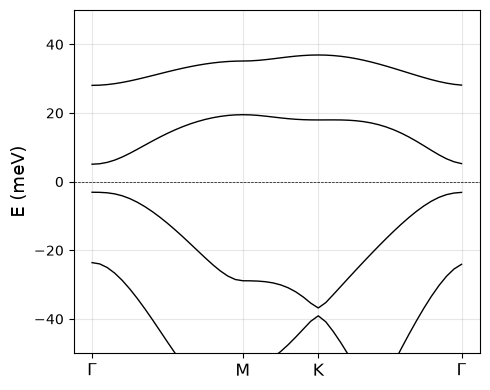

In [154]:
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_x = np.stack([1,0]) #b0方向的坐标
G_coord_y = np.stack([0,1]) #b2方向的坐标
G_coord = np.array([(m,n) for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
lenG = len(Gs)

"""构造moire周期势 Delta_t/b """
Delta_1 = np.zeros((lenG, lenG), dtype=complex)
Delta_2 = np.zeros((lenG, lenG), dtype=complex)
b_allowed = [G_coord_x, G_coord_y, -G_coord_x-G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed):
        coord_prime = coord + bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_1 [k,i] = V * np.exp(+1j * psi)
            Delta_2 [k,i] = V * np.exp(-1j * psi)
        coord_prime = coord - bj
        if -Nbloch <= coord_prime[0] <= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_1 [k,i] = V * np.exp(-1j * psi)
            Delta_2 [k,i] = V * np.exp(+1j * psi)
            
""" 构造隧穿矩阵T"""
T = np.zeros((lenG, lenG))
b_allowed_for_T = [G_coord_x-G_coord_x , G_coord_y, G_coord_x+G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed_for_T):
        coord_prime = coord - bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            T [k,i] = w
        
H0_non_diag = np.block([[Delta_1, T],[T.conj().T, Delta_2]])

"""计算H0中的动能项"""
def calc_H0_diag(k, Gs, Kt, Kb):
    # 我现在的基底是bloch平面波psi_i，我的每个基底在p算符下的动量为k->k+G_i
    diagts = []
    diagbs = []
    for i, Gi in enumerate(Gs):
        diagt = -h2m * (np.linalg.norm(k  + Gi - Kb)) **2
        diagb = -h2m * (np.linalg.norm(k  + Gi - Kt)) **2
        diagts.append(diagt)
        diagbs.append(diagb)
    H0diag = np.diag(diagts + diagbs)
    return H0diag

"""高对称点路径上每一个点进行对角化"""
def kpoints(start, end, n):
    return [start + i/n * (end - start) for i in range(n)]
G = np.array([0.0, 0.0])
M = bM * np.array([+1/2, 0.0])
Kplus = bM * np.array([-1/2, +1/(2*np.sqrt(3))])
Kminus = bM * np.array([-1/2, -1/(2*np.sqrt(3))])
Kp = bM * np.array([+1/2, -1/(2*np.sqrt(3))])
KK = bM * np.array([+1/2, +1/(2*np.sqrt(3))])

knum = np.array([10,5,10]) * 2
kpath = (kpoints(G,M,knum[0])+ kpoints(M, KK, knum[1]) + kpoints(KK, G, knum[2]))
eigvals = []
for k in tqdm.tqdm(kpath):
    H0_diag = calc_H0_diag(k, Gs, Kt, Kb)
    H0 = H0_non_diag + H0_diag
    evals, _ = np.linalg.eigh(H0)
    eigvals.append(evals)
eigvals = np.array(eigvals)   
Nk = eigvals.shape[0]         
dim = eigvals.shape[1]   
k_index = np.arange(Nk)
E_min, E_max = -50, 50
plt.figure(figsize=(5, 4))

for n in range(dim):
    E_n = eigvals[:, n] * 1000 
    if (E_min < E_n.max() and E_max > E_n.min()):
        plt.plot(k_index, E_n , lw=1.0, color = 'k')

kk2 = [0] + np.cumsum(knum).tolist()
kk2[-1] -= 1
kk1 = [ r"$\Gamma$", "M", "K",  r"$\Gamma$"]
plt.xticks(kk2, kk1, fontsize=12)
plt.ylabel('E (meV)', fontsize=13)
plt.ylim(E_min, E_max)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [102]:
Ec = eigvals[:,-1]
Ec.max()-Ec.min() #大约陈带的动能在8meV

np.float64(0.008852582010167712)

##  计算陈数 ##

100%|██████████| 26/26 [01:25<00:00,  3.27s/it]


chern_number -1.00000 band -1


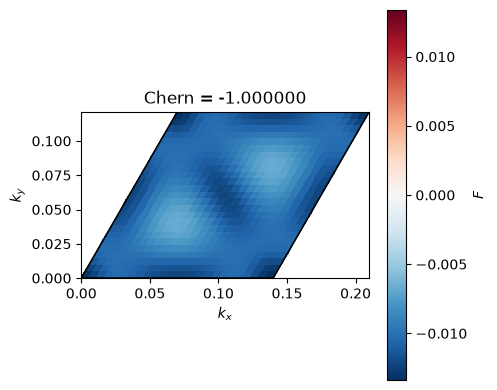

In [160]:
def calc_chern (bx, by, step, band_id):
    dbx = bx/step
    dby = by/step
    
    vecs = np.zeros((step+1, step+1, dim), dtype = complex)
    eband = np.zeros((step+1, step+1))
    for i in tqdm.tqdm(range(0,step+1)):
        for j in range(0,step+1):
            k = i * dbx + j * dby
            H0tot = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
            e , v = np.linalg.eigh(H0tot)
            vecs[i,j,:] = v[:,band_id]
            eband[i,j] = e[band_id]
    
    F = np.zeros((step,step))
    for i in range(0,step):
        for j in range(0,step):
            vs = [vecs[i,j,:], vecs[i+1,j,:],vecs[i+1,j+1,:],vecs[i,j+1,:]]   
            ua = np.vdot(vs[0],vs[1]) 
            ub = np.vdot(vs[1],vs[2])
            uc = np.vdot(vs[2],vs[3])
            ud = np.vdot(vs[3],vs[0])
            Zi = ua*ub*uc*ud
            F[i,j] = np.angle(Zi)
    return F

def plot_F(F, b0, b1, step):
    b0 = np.asarray(b0, dtype=float).reshape(2)
    b1 = np.asarray(b1, dtype=float).reshape(2)
    I, J = np.meshgrid(np.arange(step + 1), np.arange(step + 1), indexing='ij')
    X = I * (b0[0] / step) + J * (b1[0] / step)
    Y = I * (b0[1] / step) + J * (b1[1] / step)

    vmax = np.abs(F).max() or 1.0

    fig, ax = plt.subplots(figsize=(5, 4))
    mesh = ax.pcolormesh(X, Y, F.T, cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax, shading='flat')

    # BZ 边界
    corners = np.array([[0, 0], b0, b0 + b1, b1, [0, 0]])
    ax.plot(corners[:, 0], corners[:, 1], 'k-', lw=1.2)
    
    fig.colorbar(mesh, ax=ax, label=r'$F$')
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$'); ax.set_ylabel(r'$k_y$')
    ax.set_title(f'Chern = {F.sum()/(2*np.pi):.6f}')
    plt.tight_layout(); plt.show()

step = 25
band_id = -1
F = calc_chern(b[0], b[1], step, band_id)
ch = np.sum(F[:step, :step]) / (2 * np.pi)
print(f"chern_number {ch:.5f} band {band_id}")
plot_F(F,b[0],b[1], step)

##  H0的周期性 ##

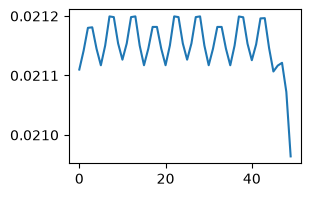

In [60]:
path = kpoints(-5*KK,5*KK,50)
etot = []
for  i,k in enumerate(path):
    H0 = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
    e,v = np.linalg.eigh(H0)
    etot.append(e[-1])
plt.figure(figsize=(3, 2))
plt.plot(etot)

##  相互作用投影到陈带 ##

In [155]:
N1 = 4 #实空间30°方向的原胞数量
N2 = 6 #实空间-90°方向的原胞数量
N = N1*N2 #总采样数量
nu = 2/3
Ne = int(np.round(N * nu))
A = A_cell * N
band_id = -1 #chern带标记
e_square_div_epsilon_0 = 180.95 #(unit in e^2 * angstrom )
epsilonx2 = 15*2 #e^2 * tanh(|q|d)/(epsilon_0 * 2 * epsilon_r * |q|)
dist = 300 #(unit in Angstrom)

In [156]:
"""生成采样点"""
bias_x = 0
bias_y = 0
ks = np.array([(j+bias_x)*b[0]/N1 + (i+bias_y)*b[2]/N2 for i in range(0,N2) for j in range(0,N1)])
kmesh = ks
kmesh = np.array(kmesh)
assert len(kmesh) == N #检查生成的采样点数量
dimBloch = (2*Nbloch + 1) ** 2

"""计算每个k采样点上的单粒子波函数"""
kvecs = np.zeros((N, dim), dtype = np.complex128)#每个采样点存一个波函数向量
keigs = np.zeros(N) #每个采样点的能量本征值
for i,k in enumerate(kmesh):
    H0 = H0_non_diag+ calc_H0_diag(k,Gs,Kt,Kb)
    eig, eigvec = np.linalg.eigh(H0)
    kvecs[i,:] = eigvec[:,band_id]
    keigs[i] = eig[band_id]

"""计算库伦相互作用矩阵元"""
cons_e = e_square_div_epsilon_0 / epsilonx2 / A
def calc_cons_q(q):
    q_norm = np.linalg.norm(q)
    t = q_norm * dist
    tt= 1
    if t < 5: 
        tt = math.tanh(t)
    cons =  cons_e * tt / q_norm #cons大约在1-6meV之间
    return cons
    
#晶格动量的转移可以是两个对角格点相减，因此会是2倍大小的Gs
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_ext = np.array([(m,n) for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])
Gs_ext = np.array([m*b[0] + n*b[2] for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])

def calc_interaction(kvecs,i,j,k,l):
    #限制q在一个mBZ中，如果q匹配成功，那么遍历所有的G,去匹配G
    # i -> k 匹配 j -> l
    k1 = kmesh[i]
    k2 = kmesh[j]
    k3 = kmesh[k]
    k4 = kmesh[l]
   # if i == 2 and j == 1 and k ==3 and l == 0:
        #print(k1,k2,k3,k4)
    if np.linalg.norm((k1 - k3) - (k4 - k2)) < 1e-8 and np.linalg.norm(k1 - k3) > 1e-8:
        #遍历所有的截断晶格向量
        V_int = 0
        for g_coord in G_coord_ext: #k1 = k3 + q + G, k2 = k4 - q - G
            g = g_coord[0]*b[0] + g_coord[1]*b[2]
            F1 = calc_form_factor(kvecs[i,:],kvecs[k,:], g_coord)
            F2 = calc_form_factor(kvecs[j,:],kvecs[l,:], -g_coord)
            V_int += calc_cons_q(k1 - k3 - g) * F1 * F2
        return V_int
    else:
        return 0

def coord_to_index(x,y):
    idx = (2*Nbloch + 1)*(x+Nbloch) + (y+Nbloch)
    return idx
    
def calc_form_factor(vec1,vec2,g_coord):
    #form factor需要按照层内匹配去计算
    x1 = max([-Nbloch + g_coord[0] , -Nbloch])
    x2 = min([+Nbloch + g_coord[0] , +Nbloch])
    y1 = max([-Nbloch + g_coord[1] , -Nbloch])
    y2 = min([+Nbloch + g_coord[1] , +Nbloch])
    
    form_factor = 0
    for xi in range(x1,x2+1):
        for yi in range(y1,y2+1):
            form_factor_b  = vec1[coord_to_index(xi,yi)].conj() * vec2[coord_to_index(xi-g_coord[0],yi-g_coord[1])] #top 层
            form_factor_t = vec1[coord_to_index(xi,yi)+dimBloch].conj() * vec2[coord_to_index(xi-g_coord[0],yi-g_coord[1])+dimBloch] #bottom层
            form_factor +=  (form_factor_b + form_factor_t)
    return form_factor

"""记录所有的交换动量匹配的4点矩阵元"""
"""规定产生算符是按照升序序号排列，湮灭算符是按照降序序号排列"""
""" i -> k j -> l，i,j是需要湮灭的占据，k,l是产生的占据"""
""" +V -> (l < k, i > j)"""
V_pairs = []
for i in tqdm.tqdm(range(1,N)):
    for j in range(0,i):
        #这里只规定ij的降序顺序，kl的顺序我不规定，因为有两种构型，需要区分费米子符号
        for k in range(0,N):
            for l in range(0,N):
                if (l == k) or (l ==j) or (l == i) or (k == i) or (k == j) or ((k - i + l - j) != 0): #平行四边形这点很好判断，如果不是平行四边形就不成立
                    continue 
                v = calc_interaction(kvecs,i,j,k,l)
                if v == 0:
                    continue
                if k > j:
                    V_pairs.append([v,i,j,k,l]) #i -> k j ->l
                else:
                    V_pairs.append([-v,i,j,k,l]) # k< l就是在挖掉ij的态上先生成左边的k再生成右边的l，l要越过k出现负号


100%|██████████| 23/23 [25:52<00:00, 67.48s/it] 


## 按照总动量分块对角化 ##

In [157]:
basis = spinless_fermion_basis_1d(L=N, Nf=Ne)
print("basis dimension:", basis.Ns)  

r = np.arange(N1)
q = np.arange(N2)
N = N1*N2
k_table = np.array([(x,y) for y in q for x in r])
klen = len(k_table)
E_table = (keigs.max() - keigs)

def state_to_eig(idx):
    e = 0
    for j in range(N):
        bit = ((idx >> j) & 1)
        e +=  bit * E_table[N-j-1]
    return e
    
def state_to_coord(idx):
    coord = 0
    for j in range(N):
        bit = ((idx >> j) & 1)
        coord +=  bit * k_table[N-j-1]
    return (coord[0] % N1, coord[1] % N2)

#tags[i] 记录了K=i的所有态的集合
tags = []
for i in range(klen):
    tags.append([])

#对basis的总动量分类
for i in tqdm.tqdm(range(basis.Ns)):
    st = basis.states[i]
    coord = state_to_coord(st)
    coord_l = coord[0] + N1 * coord[1]
    tags[coord_l].append(st)

basis dimension: 735471


100%|██████████| 735471/735471 [02:59<00:00, 4104.21it/s]


V_pairs:2528


  4%|▍         | 1/24 [09:46<3:44:45, 586.33s/it]

[-4.21651643 -2.3399857  -1.9904868  -1.68548482 -1.45306923 -0.80796654
 -0.6068636  -0.51138363 -0.15135393  0.03850449  0.19476505  0.19748085
  0.22868202  0.29404766  0.51393156  0.63917959  0.79332977  0.89023534
  0.92920751  1.11360279]


  8%|▊         | 2/24 [19:30<3:34:34, 585.21s/it]

[-2.84573481 -1.87608551 -1.58399562 -1.30742767 -1.03902236 -0.76652616
 -0.71054849 -0.34974268 -0.20656121  0.01374078  0.139907    0.30805117
  0.5169766   0.77649163  0.82357049  0.97625878  1.00972829  1.1468996
  1.35534357  1.39072246]


...

[-2.48504735 -2.18641221 -1.90586285 -1.13440492 -0.83113539 -0.63248728
 -0.47006263 -0.03869915  0.09325225  0.14227873  0.5359281   0.7202053
  0.76985032  0.864187    0.99252374  1.16965596  1.22060588  1.31922647
  1.46180163  1.50947088]


 96%|█████████▌| 23/24 [3:47:24<10:04, 604.09s/it]

[-3.44568303 -2.57316428 -2.28340349 -2.1977468  -1.8602378  -1.38728484
 -1.20801215 -1.02400603 -0.86243533 -0.41563519 -0.18021597 -0.03181619
  0.08707401  0.17508755  0.34369152  0.45548896  0.59629083  0.70091369
  0.80649955  0.87786881]


100%|██████████| 24/24 [3:57:22<00:00, 593.44s/it]

[-2.52860481 -1.1000503  -0.91654686 -0.16331136 -0.05010009  0.07047714
  0.07091882  0.12193697  0.26682084  0.40296905  0.55003854  0.56374893
  0.7181835   0.94709829  0.97517351  1.05290541  1.19615094  1.24118239
  1.34725348  1.47055808]
-50


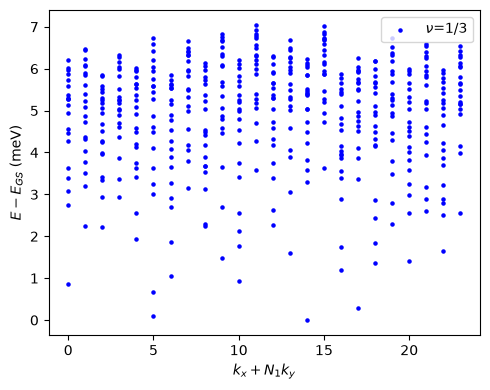

In [158]:
#V_array记录所有形如 cl+ck+ci-cj-的相互作用算符 i>j 用来查找
#V_dict用来快速查找符合的形状
V_dict = {} 
V_array = np.zeros((N, N, N, N), dtype=np.complex128)
print(f"V_pairs:{len(V_pairs)}")
for V, i, j, k, l in tqdm.tqdm(V_pairs):
    V_array[i, j, k, l] = V
    V_dict[((1 << i) | (1 << j) | (1 << k) | (1 << l))] = 1

#对于某一个block K=i，两两态之间做xor
#Block_V = np.zeros((len(tags[0]), len(tags[0])),dtype = np.complex128)
eigs_tot = []
for i in tqdm.tqdm(range(klen)):
    rows = []
    cols = []
    data = []
    #print(f"momentum:{i} dim:{len(tags[i])}")

    ltags = len(tags[i])
    for p in range(len(tags[i])):
        
        #对角项
        E = state_to_eig(tags[i][p])
        rows.append(p)
        cols.append(p)
        data.append(E)
        
        for q in range(0,p):
            x = tags[i][p] ^ tags[i][q]
            if x.bit_count() == 4 and V_dict.get(x,0):
                t1 = []
                t2 = []
                for t in range(N):
                    tt = (1 << t)
                    if (tt & tags[i][p]) and ((tt & tags[i][q]) ==0) :
                        t1.append(N-1-t) #t1[1] 是 j t1[0] 是 i
                    if (tt & tags[i][q]) and ((tt & tags[i][p]) ==0):
                        t2.append(N-1-t)
                z = ((p << (t1[1]+1)) >>(t1[1]+1+N-t1[0])).bit_count()+((p << (t2[1]+1)) >> (t2[1]+1+N-t2[0])).bit_count()
                z = (-1)**z
                v_pq = z * (V_array[t1[0],t1[1],t2[0],t2[1]] + V_array[t1[0],t1[1],t2[1],t2[0]])
                rows.append(p)
                cols.append(q)
                #ij->kl如果合法，那么ij->lk也合法。我在V_pair时已经规定l<k为正序，V_pair中的符号已经是正确的了
                data.append(v_pq)
                rows.append(q)
                cols.append(p)
                data.append(v_pq.conj())
    
    sps = coo_matrix((data, (rows, cols)), shape=(len(tags[i]), len(tags[i])))
    eigs, _ = eigsh(sps, k=20, which='SA')
    eigs_sorted = np.sort(eigs)
    eigs_tot.append(eigs_sorted)
    print(eigs_sorted*1000)

def plot_spectrum_block(es):
    points = []
    for i in range(len(es)):
        for j in range(len(es[i])):
            points.append((i,es[i][j]))
    Emin = min(j for _, j in points)
    print(E_min)
    points = np.array(points)
    
    k_vals = points[:, 0]
    E_vals = (points[:, 1] - Emin)*1000
    plt.figure(figsize=(5, 4))
    plt.scatter(k_vals, E_vals, s=5, c='b',label = fr"$\nu$=1/3")
    plt.xlabel(r'$k_x + N_1 k_y$')
    plt.ylabel(r'$E -E_{GS}$ (meV)')
    plt.tight_layout()
    plt.legend(loc='upper right')
    plt.show()
    
plot_spectrum_block(eigs_tot)

In [159]:
np.savez('Grid_4x6_tMoTe2_WangChong_nu_eq_-2_3.npz', Nlobch = Nbloch, nu = nu, eigs = eigs_tot)